In [1]:
!pip install transformers


In [2]:
# Install dependencies
!pip install transformers datasets scikit-learn
import random
import numpy as np
import torch
import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Load all four labeled CSV files
df1 = pd.read_csv("LD DA 1.csv")
df2 = pd.read_csv("LD EL1.csv")
df3 = pd.read_csv("LD PF1.csv")
df4 = pd.read_csv("LD TS 1.csv")

# Combine into one dataframe
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Drop missing values
df = df.dropna(subset=['title', 'selftext', 'Label'])

# Combine title + selftext as input
df['text'] = df['title'] + " " + df['selftext']



In [3]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Normalize labels
label_mapping = {
    'Drug and Alcohol': 'Drug and Alcohol',
    'Drug and alcohol': 'Drug and Alcohol',
    'drug and Alcohol': 'Drug and Alcohol',
    'drug and alcohol': 'Drug and Alcohol',
    'Early Life': 'Early Life',
    'Early life': 'Early Life',
    'early life': 'Early Life',
    'Personality': 'Personality',
    'personality': 'Personality',
    'Trauma and Stress': 'Trauma and Stress',
    'Trauma and Stress ': 'Trauma and Stress',
    'trauma and stress': 'Trauma and Stress'
}
df['Label'] = df['Label'].map(label_mapping)


df['label_encoded'] = label_encoder.fit_transform(df['Label'])
num_labels = len(label_encoder.classes_)

# Save label mapping
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_map)

from transformers import XLNetTokenizer

tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

encodings = tokenizer(
    df['text'].tolist(),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors='pt'
)

import torch
labels = torch.tensor(df['label_encoded'].tolist())

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label_encoded']),
    y=df['label_encoded']
)
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

Label Mapping: {'Drug and Alcohol': np.int64(0), 'Early Life': np.int64(1), 'Personality': np.int64(2), 'Trauma and Stress': np.int64(3)}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

In [4]:

from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(
    encodings['input_ids'],
    encodings['attention_mask'],
    labels
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)


from transformers import XLNetForSequenceClassification

model = XLNetForSequenceClassification.from_pretrained(
    'xlnet-base-cased',
    num_labels=num_labels
)
model.to(device)



pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLNetForSequenceClassification(
  (transformer): XLNetModel(
    (word_embedding): Embedding(32000, 768)
    (layer): ModuleList(
      (0-11): 12 x XLNetLayer(
        (rel_attn): XLNetRelativeAttention(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): XLNetFeedForward(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (layer_1): Linear(in_features=768, out_features=3072, bias=True)
          (layer_2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation_function): GELUActivation()
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (sequence_summary): XLNetSequenceSummary(
    (summary): Linear(in_features=768, out_features=768, bias=True)
    (activation): Tanh()
    (first_dropout): Identity()
    


🔁 Epoch 1/10


  0%|          | 0/160 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

100%|██████████| 160/160 [01:21<00:00,  1.96it/s]


✅ Epoch 1 complete. Avg loss: 1.3787
📊 Validation Accuracy: 0.3625
💾 Best model saved with accuracy: 0.3625

🔁 Epoch 2/10


...

✅ Epoch 8 complete. Avg loss: 0.0608
📊 Validation Accuracy: 0.8313

🔁 Epoch 9/10


100%|██████████| 160/160 [01:25<00:00,  1.88it/s]


✅ Epoch 9 complete. Avg loss: 0.0295
📊 Validation Accuracy: 0.8375

🔁 Epoch 10/10


100%|██████████| 160/160 [01:25<00:00,  1.88it/s]


✅ Epoch 10 complete. Avg loss: 0.0370
📊 Validation Accuracy: 0.8438

📋 Final Classification Report:
                   precision    recall  f1-score   support

 Drug and Alcohol     0.8776    0.9556    0.9149        45
       Early Life     0.7857    0.7586    0.7719        29
      Personality     0.8696    0.8511    0.8602        47
Trauma and Stress     0.8108    0.7692    0.7895        39

         accuracy                         0.8438       160
        macro avg     0.8359    0.8336    0.8341       160
     weighted avg     0.8423    0.8438    0.8423       160



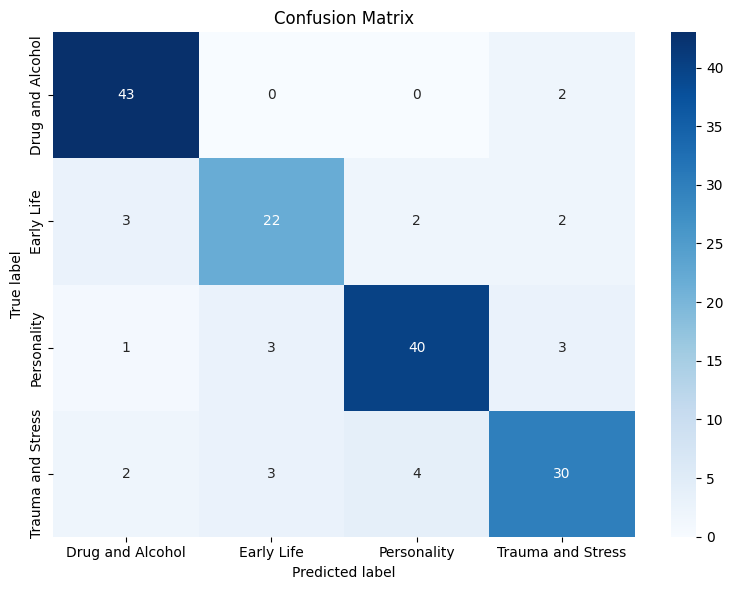

 Overall Accuracy   : 0.8438
 Macro Avg F1-score : 0.8341
 Weighted Avg F1    : 0.8423

 Per-Class Accuracy:
Drug and Alcohol    : 0.9556 (43/45)
Early Life          : 0.7586 (22/29)
Personality         : 0.8511 (40/47)
Trauma and Stress   : 0.7692 (30/39)


In [5]:
# -----------------------------------
# 6. Set up training loop
# -----------------------------------
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
import torch

optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

best_accuracy = 0.0
save_path = "best_model_xlnet.pth"
num_epochs = 10

# Reduce batch size to mitigate OOM error and use gradient accumulation
batch_size = 4
gradient_accumulation_steps = 4 # Accumulate gradients over 4 batches

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)


for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    print(f"\n🔁 Epoch {epoch + 1}/{num_epochs}")

    optimizer.zero_grad() # Zero gradients at the beginning of each epoch

    for step, batch in enumerate(tqdm(train_loader)):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = loss_fn(outputs.logits, labels)
        loss = loss / gradient_accumulation_steps # Normalize loss

        loss.backward()
        total_loss += loss.item() * gradient_accumulation_steps # Accumulate total loss

        if (step + 1) % gradient_accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

    # Perform optimizer step for remaining gradients if any
    if (step + 1) % gradient_accumulation_steps != 0:
        optimizer.step()
        optimizer.zero_grad()


    avg_loss = total_loss / len(train_loader)
    print(f"✅ Epoch {epoch + 1} complete. Avg loss: {avg_loss:.4f}")

    # ------------------- Validation -------------------
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"📊 Validation Accuracy: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        torch.save(model.state_dict(), save_path)
        print(f"💾 Best model saved with accuracy: {best_accuracy:.4f}")

# # -----------------------------------
# # 7. Final evaluation
# # -----------------------------------
# print("\n📋 Classification Report:")
# report = classification_report(all_labels, all_preds, digits=4, target_names=label_encoder.classes_)
# print(report)

# -----------------------------------
# 7. Final Evaluation (Extended)
# -----------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("\n📋 Final Classification Report:")
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_,
    output_dict=True,
    digits=4
)

# Print formatted report
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("confusion_matrix_xlnet.png")
plt.show()

# --- Optional: Convert report to DataFrame for detailed inspection ---
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("classification_report_xlnet.csv", index=True)

# --- Print extra insights ---
print(f" Overall Accuracy   : {report_dict['accuracy']:.4f}")
print(f" Macro Avg F1-score : {report_dict['macro avg']['f1-score']:.4f}")
print(f" Weighted Avg F1    : {report_dict['weighted avg']['f1-score']:.4f}")

# --- Per-class accuracy (extra) ---
print("\n Per-Class Accuracy:")
for idx, class_name in enumerate(label_encoder.classes_):
    class_support = cm[idx].sum()
    correct_preds = cm[idx][idx]
    class_acc = correct_preds / class_support if class_support > 0 else 0.0
    print(f"{class_name:20}: {class_acc:.4f} ({correct_preds}/{class_support})")




In [29]:
text = "my work is stressing me out"

# Tokenize
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

# Decode predicted class
predicted_label = label_encoder.inverse_transform([pred])[0]

print("Predicted label:", predicted_label)


Predicted label: Trauma and Stress


In [30]:
text = "i did too many drugs so i don't have money and now i want to die"

# Tokenize
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

# Decode predicted class
predicted_label = label_encoder.inverse_transform([pred])[0]

print("Predicted label:", predicted_label)


Predicted label: Drug and Alcohol


In [31]:
text = "i had a very bad childhood and it still affects my moods in adult life"

# Tokenize
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

# Decode predicted class
predicted_label = label_encoder.inverse_transform([pred])[0]

print("Predicted label:", predicted_label)


Predicted label: Early Life


In [32]:
text = "i don't like myself very much"

# Tokenize
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

# Decode predicted class
predicted_label = label_encoder.inverse_transform([pred])[0]

print("Predicted label:", predicted_label)


Predicted label: Personality
